<a href="https://colab.research.google.com/github/cinth90/Datascience1/blob/main/ProyectoDS_ParteIII_Debenedetto_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final: Predicción de cancelaciones de reservas de hotel.
*Entrega Final*

**Abstract**

Este proyecto utiliza el dataset “Hotel bookings” proveniente de Kaggle, que contiene más de 119.000 reservas de hoteles realizadas durante 2015 y 2017. La base de datos incluye datos de un resort y un city hotel, con información sobre país de origen del huesped, fecha de llegada, duración de la estadia, tipo de cuarto, precio promedio por noche, si viajan menores o bebes y requerimientos del huesped entre otros datos no relevantes para este analisis.

El objetivo del proyecto es explorar de donde provienen la mayoria de los huesped y si se observa alguna estacionalidad de las reservas a lo largo del anio. Para lo que se responderan preguntas de interés para el analisis de este dataset. Para ello se aplican técnicas de análisis de datos, utilizando herramientas como Matplotlib, Seaborn y pandas.

Se comienza con una limpieza básica y detección de valores faltantes, seguida de visualizaciones que permiten responder preguntas clave. Este análisis exploratorio permitirá sentar las bases para futuros trabajos de predicción, segmentación o recomendaciones de estrategias de marketing.


# Preguntas para el analisis


1. De que 6 pais provienen la mayoria de los huspedes?
2. De los 6 paises con mas reservas, cuantas cancelaciones y no shows tiene cada uno?
3. En que semana del anio hay mas reservas con ninios?
4.  Cuanto es el precio promedio por noche de cada tipo de cuarto?
  Como evoluciona el precio de la noche durante el anio segun tipo de cuarto?



#Prediccion de cancelacion de reservas

Se desea probar las siguientes teorias:

1. Cuanto más días de anticipación tiene la reserva mayor probabilidad de ser cancelada
2. Las estadias con mayor cantidad de requerimientos especiales están ligadas a estadías más largas
3. Las estadias con mas requerimientos especiales tienen menos cancelaciones
4. Las reservas con mayor anticipación se traducen en estadias mas largas

#Nombre de columnas: traduccion y descripcion

Hotel: Tipo de hotel: "City Hotel" o "Resort Hotel."

is_canceled: cancelada: Valor binario donde el 1 indica que fue cancelada y 0 no.

lead_time: reserva_anticipacion_dias: Numero de dias entre la reserva y la llegada al hotel.

arrival_date_year:llegada_anio: Anio de la fecha de llegada al hotel.

arrival_date_month:llegada_mes: Mes de la fecha de llegada al hotel.

arrival_date_week_number: llegada_semana: Numero de semana de la fecha de la llegada.

arrival_date_day_of_month: llegada_dia_del_mes: Dia de la fecha de llegada al hotel.

stays_in_weekend_nights: estadia_fines_de_semana_noches: Numero de noches de fin de semana (Sabado o Domingo) que el huesped se alojo durante su estadia.

stays_in_week_nights: estadia_lun_a_vie_noches: Numero de noches de semana (Lunes a Viernes) que el huesped se alojo durante su estadia.

adults: adultos:Cantidad de adultos.

children: menores: Cantidad de menores.

babies: bebes Cantidad de bebes.

meal: comida: Tipo de comida reservada.

country: huesped_pais: Pais de origen del huesped.

market_segment: segmento_de_mercado: segmento de mercado.

distribution_channel: reserva_canal: Canal de distribucion de la reserva.

is_repeated_guest:huesped_repetido: Valor binario que indica si no es la primer reserva del huesped (1) si repite o (0) si es la primer reserva.

previous_cancellations: reserva_previa_cancelada: Numero de reservas previas canceladas.

previous_bookings_not_canceled: reserva_previa_usada :Numero de reservas previas no canceladas.

reserved_room_type: cuarto_tipo_reserva Codigo del tipo de cuarto reservado.

assigned_room_type: cuarto_tipo_asignado Codigo del tipo de cuarto asignado durante el check-in.

booking_changes: reserva_cambios Number of changes/amendments made to the booking.

deposit_type: deposito_tipo: Tipo de desposito hecho.

agent: agente: Id del agente de viajes.

company:compania_id: ID de la compania.

days_in_waiting_list:dias_en_lista_espera: Numero de dias en lista de espera antes de reservar.

customer_type: reserva_tipo: tipo de reserva.

adr:precio_promedio_noche: Promedio del precio por noche.

required_car_parking_spaces:estacionamiento: Numero de estacionamientos requerido en la reserva.

total_of_special_requests:requerimientos_especiales Numero de requerimientos especiales hechos en la reserva.

reservation_status:reserva_estado: Ultimo estado de la reserva (check-out, canceled, Noshow).

reservation_status_date:reserva_ultima_actulizacion: Fecha de la ultima actualizacion del estado de la reserva.

**Datos descartados**
Estos datos fueron descartados antes de comenzar el analisis por no ser relavantes para el estudio.

name: huesped_nombre: Nombre del huesped.

email:huesped_mail: Mail del huesped.

phone-number:huesped_tel: Telefono del huesped

credit_card:huesped_tarjeta_credito: Numero de la tarjeta de credito del huesped.

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carga de los datos

In [161]:
df = pd.read_csv('https://raw.githubusercontent.com/cinth90/hotel_reservas/refs/heads/main/hotel_bookings.csv')
df.head()

,hotel,cancelada,reserva_anticipacion_dias,llegada_anio,llegada_mes,llegada_semana,llegada_dia,estadia_fines_de_semana_noches,estadia_lun_a_vie_noches,adultos,...,deposito_tipo,agente,compania,dias_en_lista_espera,reserva_tipo,precio_promedio_noche,estacionamiento,requerimientos_especiales,reserva_estado,reserva_ultima_actulizacion
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/07/2015


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   cancelada                       119390 non-null  int64  
 2   reserva_anticipacion_dias       119390 non-null  int64  
 3   llegada_anio                    119390 non-null  int64  
 4   llegada_mes                     119390 non-null  object 
 5   llegada_semana                  119390 non-null  int64  
 6   llegada_dia                     119390 non-null  int64  
 7   estadia_fines_de_semana_noches  119390 non-null  int64  
 8   estadia_lun_a_vie_noches        119390 non-null  int64  
 9   adultos                         119390 non-null  int64  
 10  menores                         119386 non-null  float64
 11  bebes                           119390 non-null  int64  
 12  comida          

In [163]:
df.describe().round().T

,count,mean,std,min,25%,50%,75%,max
cancelada,119390.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
reserva_anticipacion_dias,119390.0,104.0,107.0,0.0,18.0,69.0,160.0,737.0
llegada_anio,119390.0,2016.0,1.0,2015.0,2016.0,2016.0,2017.0,2017.0
llegada_semana,119390.0,27.0,14.0,1.0,16.0,28.0,38.0,53.0
llegada_dia,119390.0,16.0,9.0,1.0,8.0,16.0,23.0,31.0
estadia_fines_de_semana_noches,119390.0,1.0,1.0,0.0,0.0,1.0,2.0,19.0
estadia_lun_a_vie_noches,119390.0,3.0,2.0,0.0,1.0,2.0,3.0,50.0
adultos,119390.0,2.0,1.0,0.0,2.0,2.0,2.0,55.0
menores,119386.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
bebes,119390.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0


# 1. Preparación de los datos

**Analisis de datos nulos**

In [164]:
df['precio_promedio_noche'] = df['precio_promedio_noche'].replace(0, np.nan) #reemplace precio en cero por datos vacios
print("Porcentaje de datos nulos %")
datos_nulos =(df.isna().mean()*100).round(2).sort_values(ascending=False)
datos_nulos[datos_nulos > 0]


Porcentaje de datos nulos %


,0
compania,94.31
agente,13.69
precio_promedio_noche,1.64
huesped_pais,0.41


# Tratamiento de datos nulos:

*   **compania y agente:** No van a ser tenidos en cuenta para el analisis. Por lo tanto NO se imputaran los valores faltantes.
*   **huesped_pais**: Este dato es del tipo cualitativo (nombre de un pais) y tiene una baja cantidad de datos faltantes. Este dato es necesario para llevar a cabo este estudio por lo que se decidio realizar una imputacion por vecinos cercanos (knn).


*   **precio_promedio_noche	 y menores** : Los datos nulos son minimos. Es del tipo cuantitativa por lo que se realiza una imputacion simple por la mediana.




In [165]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer # librería diseñada para rellenar datos faltantes.
from sklearn.preprocessing import LabelEncoder #sirve para codificar datos categoricos a numeros para usar knn


# Copia del dataframe para no modificar el original
df_imputed = df.copy()


#Aplicando SimpleImputer
imputer_simple = SimpleImputer(strategy='median') #rellenar nan con estrategia median-->mediana
df_imputed[['menores','precio_promedio_noche']] = imputer_simple.fit_transform(df_imputed[['menores', 'precio_promedio_noche']])
#.fit(): El imputador aprende la mediana de la columna especificada, ignorando los valores nulos.
#.transform(): El imputador aplica esa mediana para reemplazar los valores nulos en la columna.


#Aplicando KNN a un dato categorico
from sklearn.preprocessing import LabelEncoder #sirve para codificar datos categoricos a numeros para usar knn

# Paso 1: Codificar la columna
encoder = LabelEncoder()
df_imputed['huesped_pais'] = df_imputed['huesped_pais'].astype(str)
df_imputed['huesped_pais'] = encoder.fit_transform(df_imputed['huesped_pais'])

# Paso 2: Imputar con KNN
imputer_knn = KNNImputer(n_neighbors=5)
df_imputed[['huesped_pais']] = imputer_knn.fit_transform(df_imputed[['huesped_pais']])

# Paso 3: Decodificar de vuelta
df_imputed['huesped_pais'] = df_imputed['huesped_pais'].round().astype(int)
df_imputed['huesped_pais'] = encoder.inverse_transform(df_imputed['huesped_pais'])

In [166]:
datos_nulos = df_imputed.isna().sum().sort_values(ascending=False)
datos_nulos[datos_nulos > 0]


,0
compania,112593
agente,16340


#Deteccion de outliers

In [167]:
def generar_hist(df:pd.DataFrame) -> None:
    fig = plt.figure(figsize=(16,9))
    df.hist(bins=10, figsize=(16,9), layout=(3,7),alpha=0.7, edgecolor='black')
    plt.suptitle('Graficos de distribucion', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

<Figure size 1600x900 with 0 Axes>

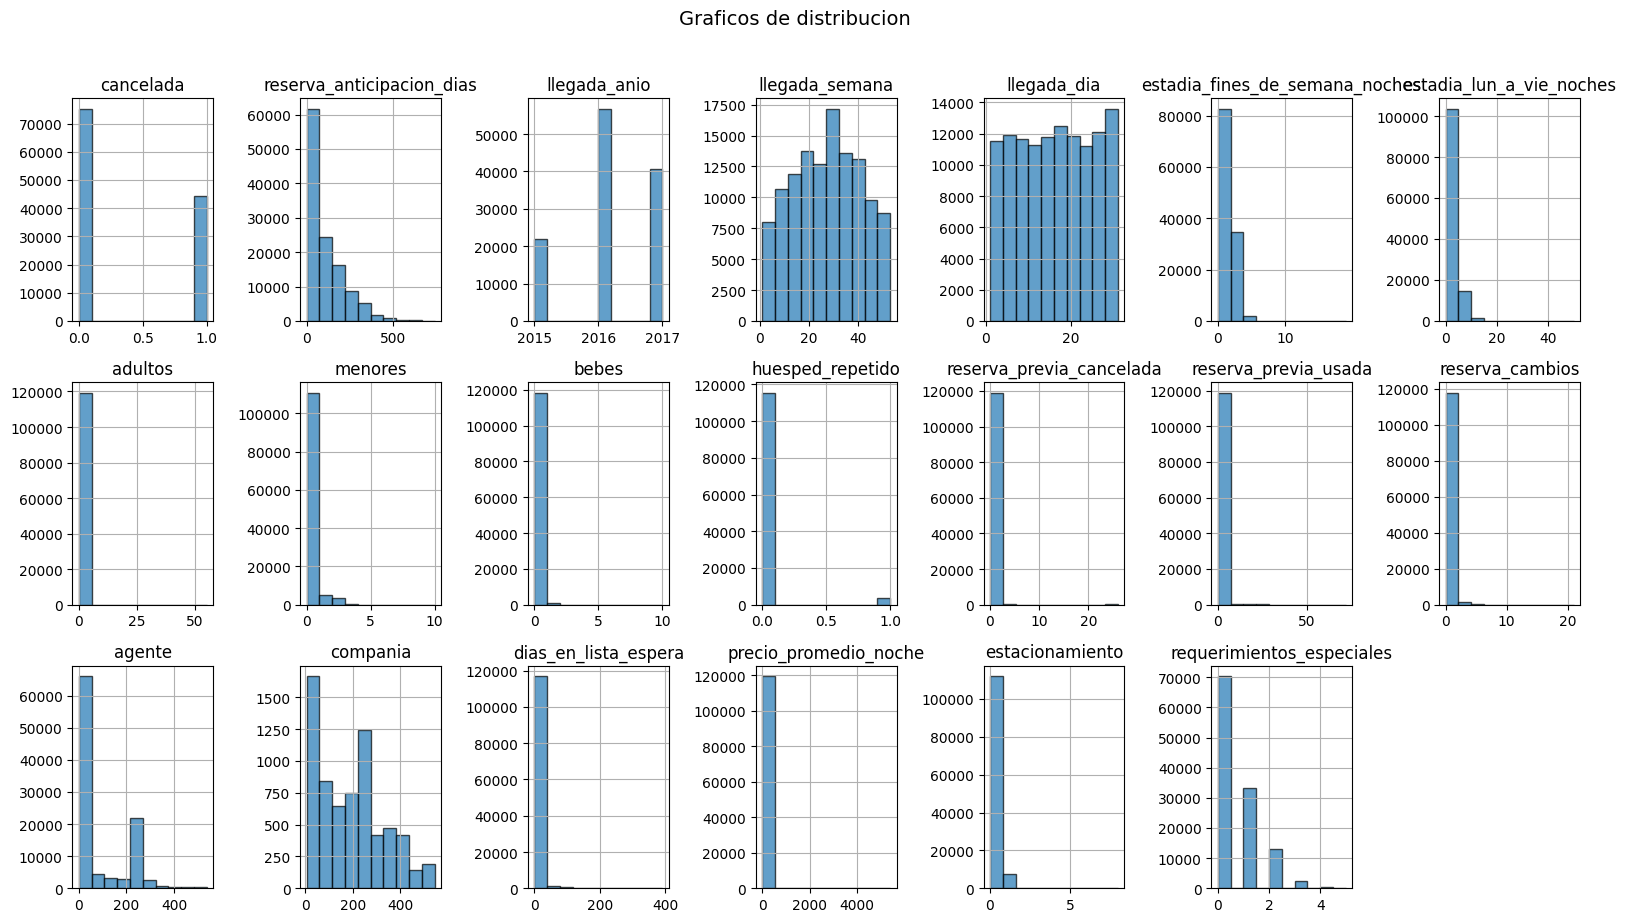

In [168]:
generar_hist(df_imputed)

#Eliminación de outliers para la duracion de la estadia

La mayoría de las estancias son cortas (1-7 noches), pero hay outliers con más de 30 noches. Estos casos pueden ser estancias extendidas de staff o clientes corporativos de larga estadía y deberían analizarse por separado en la estrategia comercial.

In [169]:
original_size = df_imputed.shape[0]
print(f"Tamaño original del dataset: {original_size}")

Tamaño original del dataset: 119390


In [170]:
# Estadía total = estadia de lun a viernes + estadia en fines de semana
df_imputed['estadia_total_noches'] = (
    df_imputed['estadia_fines_de_semana_noches'] + df_imputed['estadia_lun_a_vie_noches']
)

<Axes: xlabel='estadia_total_noches'>

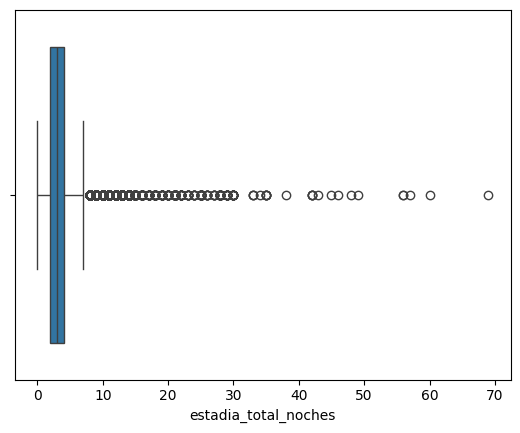

In [171]:
sns.boxplot(x=df_imputed['estadia_total_noches'])

In [172]:
Q1 =df_imputed['estadia_total_noches'].quantile(0.25)
Q3 = df_imputed['estadia_total_noches'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_imputed_IQR =df_imputed[(df_imputed['estadia_total_noches'] >= lower_bound) & (df_imputed['estadia_total_noches'] <= upper_bound)]
iqr_size = df_imputed_IQR.shape[0]
iqr_removed = original_size - iqr_size

print(f"Con IQR:")
print(f"  Tamaño final: {iqr_size}")
print(f"  Registros eliminados: {iqr_removed} ({100 * iqr_removed/original_size:.2f}%)")

Con IQR:
  Tamaño final: 114133
  Registros eliminados: 5257 (4.40%)


<Axes: xlabel='estadia_total_noches'>

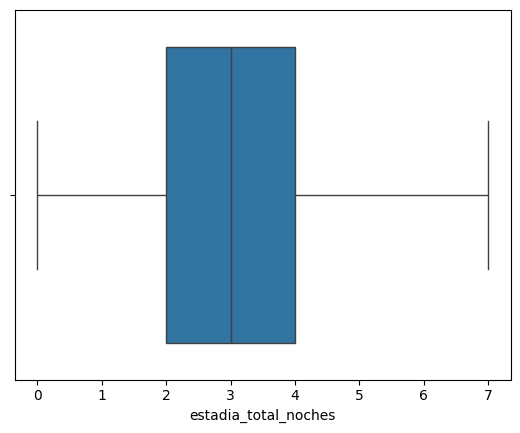

In [173]:
sns.boxplot(x=df_imputed_IQR['estadia_total_noches'])

In [174]:
df_imputed['estadia_total_noches'].describe().round(2)

,estadia_total_noches
count,119390.00
mean,3.43
std,2.56
min,0.00
25%,2.00
50%,3.00
75%,4.00
max,69.00


In [175]:
df_imputed_IQR['estadia_total_noches'].describe().round(2)

,estadia_total_noches
count,114133.00
mean,3.06
std,1.72
min,0.00
25%,2.00
50%,3.00
75%,4.00
max,7.00


#Eliminación de outliers para la anticipación en días de la reserva

Existen muchas reservas hechas con muy poca antelación (pico en los primeros días), pero también valores extremadamente altos (>300 días) que representan casos atípicos. Podrían corresponder a reservas de grupo o eventos especiales, pero conviene revisarlos para evitar distorsionar modelos de predicción.

<Axes: xlabel='reserva_anticipacion_dias'>

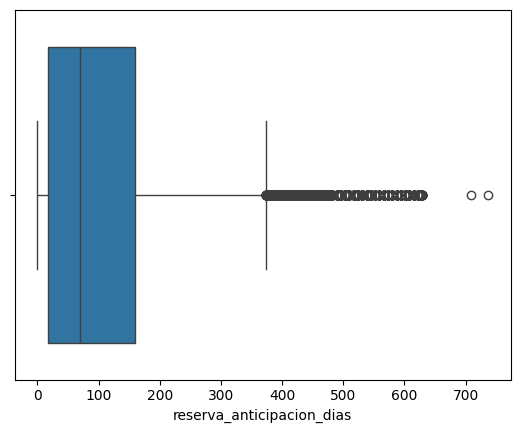

In [176]:
sns.boxplot(x=df_imputed['reserva_anticipacion_dias'])

In [177]:
Q1 =df_imputed['reserva_anticipacion_dias'].quantile(0.25)
Q3 = df_imputed['reserva_anticipacion_dias'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_imputed_IQR =df_imputed[(df_imputed['reserva_anticipacion_dias'] >= lower_bound) & (df_imputed['reserva_anticipacion_dias'] <= upper_bound)]
iqr_size = df_imputed_IQR.shape[0]
iqr_removed = original_size - iqr_size

print(f"Con IQR:")
print(f"  Tamaño final: {iqr_size}")
print(f"  Registros eliminados: {iqr_removed} ({100 * iqr_removed/original_size:.2f}%)")

Con IQR:
  Tamaño final: 116385
  Registros eliminados: 3005 (2.52%)


<Axes: xlabel='reserva_anticipacion_dias'>

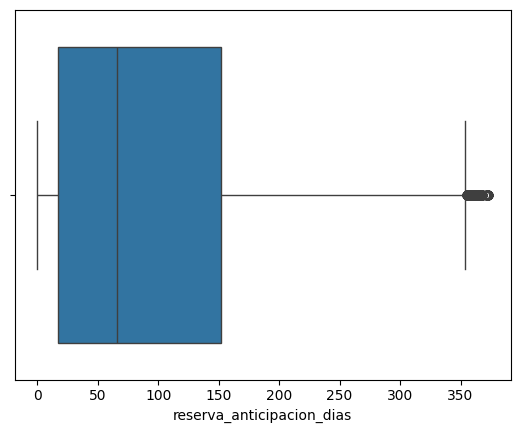

In [178]:
sns.boxplot(x=df_imputed_IQR['reserva_anticipacion_dias'])

(array([43543., 18615., 13596., 10761.,  9585.,  6577.,  4401.,  4288.,
         3186.,  1833.]),
 array([  0. ,  37.3,  74.6, 111.9, 149.2, 186.5, 223.8, 261.1, 298.4,
        335.7, 373. ]),
 <BarContainer object of 10 artists>)

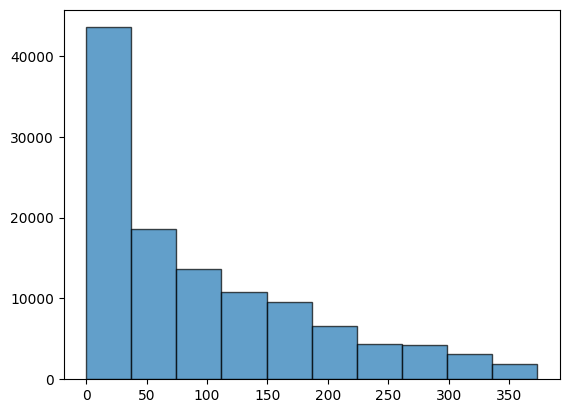

In [179]:
plt.hist(df_imputed_IQR['reserva_anticipacion_dias'],bins=10, alpha=0.7, edgecolor='black')

In [180]:
df_imputed['reserva_anticipacion_dias'].describe().round()

,reserva_anticipacion_dias
count,119390.0
mean,104.0
std,107.0
min,0.0
25%,18.0
50%,69.0
75%,160.0
max,737.0


In [181]:
df_imputed_IQR['reserva_anticipacion_dias'].describe().round()

,reserva_anticipacion_dias
count,116385.0
mean,95.0
std,92.0
min,0.0
25%,17.0
50%,66.0
75%,152.0
max,373.0


#Eliminacion de datos ruidosos y outliers

precio_promedio_noche: Los valores negativos no tienen sentido por lo que seran reemplazados con la media.

adultos: Se eliminaran las reservas que no tienen al menos un adulto porque se supone que no puede haber reservas solo con menores o bebes.

menores y bebes: Se eliminaran las reservas con mas de 10 menores por considerarlos extremos que pueden afectar el estudio.

In [182]:
# Reemplazo precio promedio negativos por la media
df_imputed_IQR.loc[df_imputed_IQR['precio_promedio_noche'] < 0, 'precio_promedio_noche'] = df['precio_promedio_noche'].median()

# ELimino filas sin adultos en la reserva
df_imputed_IQR = df_imputed_IQR[df_imputed_IQR['adultos'] != 0]

# Elimino filas con mas de 10 menores o bebes
df_imputed_IQR = df_imputed_IQR[df_imputed_IQR['menores'] <= 10]
df_imputed_IQR = df_imputed_IQR[df_imputed_IQR['bebes'] <= 10]


df_imputed_IQR.reset_index(drop=True, inplace=True)

# Crontol para ver si se manejaron los datos ruidosos
noisy_data_handled = {
    'precio_promedio_noche': df_imputed_IQR[df_imputed_IQR['precio_promedio_noche'] < 0],
    'adultos': df_imputed_IQR[df_imputed_IQR['adultos'] == 0],
    'menores': df_imputed_IQR[df_imputed_IQR['menores'] >= 10],
    'bebes': df_imputed_IQR[df_imputed_IQR['bebes'] >= 10],
}

noisy_data_handled_count = {key: len(value) for key, value in noisy_data_handled.items()}
noisy_data_handled_count

{'precio_promedio_noche': 0, 'adultos': 0, 'menores': 1, 'bebes': 1}

In [183]:
df_imputed_IQR.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
cancelada,115984.0,0.36,0.48,0.00,0.00,0.0,1.0,1.0
reserva_anticipacion_dias,115984.0,95.27,92.49,0.00,17.00,66.0,152.0,373.0
llegada_anio,115984.0,2016.15,0.71,2015.00,2016.00,2016.0,2017.0,2017.0
llegada_semana,115984.0,27.05,13.63,1.00,16.00,27.0,38.0,53.0
llegada_dia,115984.0,15.78,8.78,1.00,8.00,16.0,23.0,31.0
estadia_fines_de_semana_noches,115984.0,0.94,1.00,0.00,0.00,1.0,2.0,19.0
estadia_lun_a_vie_noches,115984.0,2.51,1.91,0.00,1.00,2.0,3.0,50.0
adultos,115984.0,1.86,0.58,1.00,2.00,2.0,2.0,55.0
menores,115984.0,0.10,0.39,0.00,0.00,0.0,0.0,10.0
bebes,115984.0,0.01,0.10,0.00,0.00,0.0,0.0,10.0


#Transformación de datos


**One-Hot Encoding:**

Las siguientes variables son categoricas por lo que se realiza un one-hot encoded:

* hotel: Es una variable categorica con dos valores: ['Resort Hotel', 'City Hotel']
* comida: Es una variable categorica. ['BB', 'FB', 'HB', 'SC', 'Undefined']
* segmento_de_mercado:Es una variable categorica. ['Direct', 'Corporate', 'Online TA', 'Offline TA/TO',
       'Complementary', 'Groups', 'Undefined', 'Aviation']
* reserva_tipo: Es una variable categorica. ['Transient', 'Contract', 'Transient-Party', 'Group']
* cuarto_tipo_reserva y cuarto_tipo_asignado: Es una variable categorica.
* deposito_tipo: Es una variable categorica.['C', 'A', 'D', 'E', 'G', 'F', 'H', 'L', 'B']

**Label Encoding:**

la variable llegada_mes tiene un orden natural por lo que se respeta su cardinalidad usando label encoded. ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' <'November' < 'December']

In [184]:
#one-hot encoding para columnas categoricas
one_hot_cols = ['hotel', 'comida', 'segmento_de_mercado', 'cuarto_tipo_reserva','cuarto_tipo_asignado', 'deposito_tipo', 'reserva_tipo']

df_imputed_IQR = pd.get_dummies(df_imputed_IQR, columns=one_hot_cols)

#Controlo que se hayan creado las nuevas columnas
df_imputed_IQR.head()

,cancelada,reserva_anticipacion_dias,llegada_anio,llegada_mes,llegada_semana,llegada_dia,estadia_fines_de_semana_noches,estadia_lun_a_vie_noches,adultos,menores,...,cuarto_tipo_asignado_I,cuarto_tipo_asignado_K,cuarto_tipo_asignado_L,deposito_tipo_No Deposit,deposito_tipo_Non Refund,deposito_tipo_Refundable,reserva_tipo_Contract,reserva_tipo_Group,reserva_tipo_Transient,reserva_tipo_Transient-Party
0,0,342,2015,July,27,1,0,0,2,0.0,...,False,False,False,True,False,False,False,False,True,False
1,0,7,2015,July,27,1,0,1,1,0.0,...,False,False,False,True,False,False,False,False,True,False
2,0,13,2015,July,27,1,0,1,1,0.0,...,False,False,False,True,False,False,False,False,True,False
3,0,14,2015,July,27,1,0,2,2,0.0,...,False,False,False,True,False,False,False,False,True,False
4,0,14,2015,July,27,1,0,2,2,0.0,...,False,False,False,True,False,False,False,False,True,False


In [185]:
df_imputed_IQR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115984 entries, 0 to 115983
Data columns (total 68 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   cancelada                          115984 non-null  int64  
 1   reserva_anticipacion_dias          115984 non-null  int64  
 2   llegada_anio                       115984 non-null  int64  
 3   llegada_mes                        115984 non-null  object 
 4   llegada_semana                     115984 non-null  int64  
 5   llegada_dia                        115984 non-null  int64  
 6   estadia_fines_de_semana_noches     115984 non-null  int64  
 7   estadia_lun_a_vie_noches           115984 non-null  int64  
 8   adultos                            115984 non-null  int64  
 9   menores                            115984 non-null  float64
 10  bebes                              115984 non-null  int64  
 11  huesped_pais                       1159

In [186]:
#label enconding para el mes de llegada
mes_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
    }

df_imputed_IQR['llegada_mes_num'] = df_imputed_IQR['llegada_mes'].map(mes_map)

#Control de que se haya cambiado como queria
df_imputed_IQR[['llegada_mes', 'llegada_mes_num']].head()

,llegada_mes,llegada_mes_num
0,July,7
1,July,7
2,July,7
3,July,7
4,July,7


In [187]:
df_imputed_IQR.head()

,cancelada,reserva_anticipacion_dias,llegada_anio,llegada_mes,llegada_semana,llegada_dia,estadia_fines_de_semana_noches,estadia_lun_a_vie_noches,adultos,menores,...,cuarto_tipo_asignado_K,cuarto_tipo_asignado_L,deposito_tipo_No Deposit,deposito_tipo_Non Refund,deposito_tipo_Refundable,reserva_tipo_Contract,reserva_tipo_Group,reserva_tipo_Transient,reserva_tipo_Transient-Party,llegada_mes_num
0,0,342,2015,July,27,1,0,0,2,0.0,...,False,False,True,False,False,False,False,True,False,7
1,0,7,2015,July,27,1,0,1,1,0.0,...,False,False,True,False,False,False,False,True,False,7
2,0,13,2015,July,27,1,0,1,1,0.0,...,False,False,True,False,False,False,False,True,False,7
3,0,14,2015,July,27,1,0,2,2,0.0,...,False,False,True,False,False,False,False,True,False,7
4,0,14,2015,July,27,1,0,2,2,0.0,...,False,False,True,False,False,False,False,True,False,7


In [188]:
df_imputed_IQR.describe().T

,count,mean,std,min,25%,50%,75%,max
cancelada,115984.0,0.363093,0.480893,0.00,0.00,0.0,1.0,1.0
reserva_anticipacion_dias,115984.0,95.273546,92.487365,0.00,17.00,66.0,152.0,373.0
llegada_anio,115984.0,2016.150305,0.710168,2015.00,2016.00,2016.0,2017.0,2017.0
llegada_semana,115984.0,27.046446,13.626601,1.00,16.00,27.0,38.0,53.0
llegada_dia,115984.0,15.779013,8.778160,1.00,8.00,16.0,23.0,31.0
estadia_fines_de_semana_noches,115984.0,0.935741,0.996498,0.00,0.00,1.0,2.0,19.0
estadia_lun_a_vie_noches,115984.0,2.512441,1.909893,0.00,1.00,2.0,3.0,50.0
adultos,115984.0,1.861688,0.575242,1.00,2.00,2.0,2.0,55.0
menores,115984.0,0.102971,0.394814,0.00,0.00,0.0,0.0,10.0
bebes,115984.0,0.008139,0.098632,0.00,0.00,0.0,0.0,10.0


#Eliminacion de datos duplicados

In [189]:
df_imputed_IQR.drop_duplicates(inplace=True)

#De que 6 pais vienen la mayoria de los huspedes?

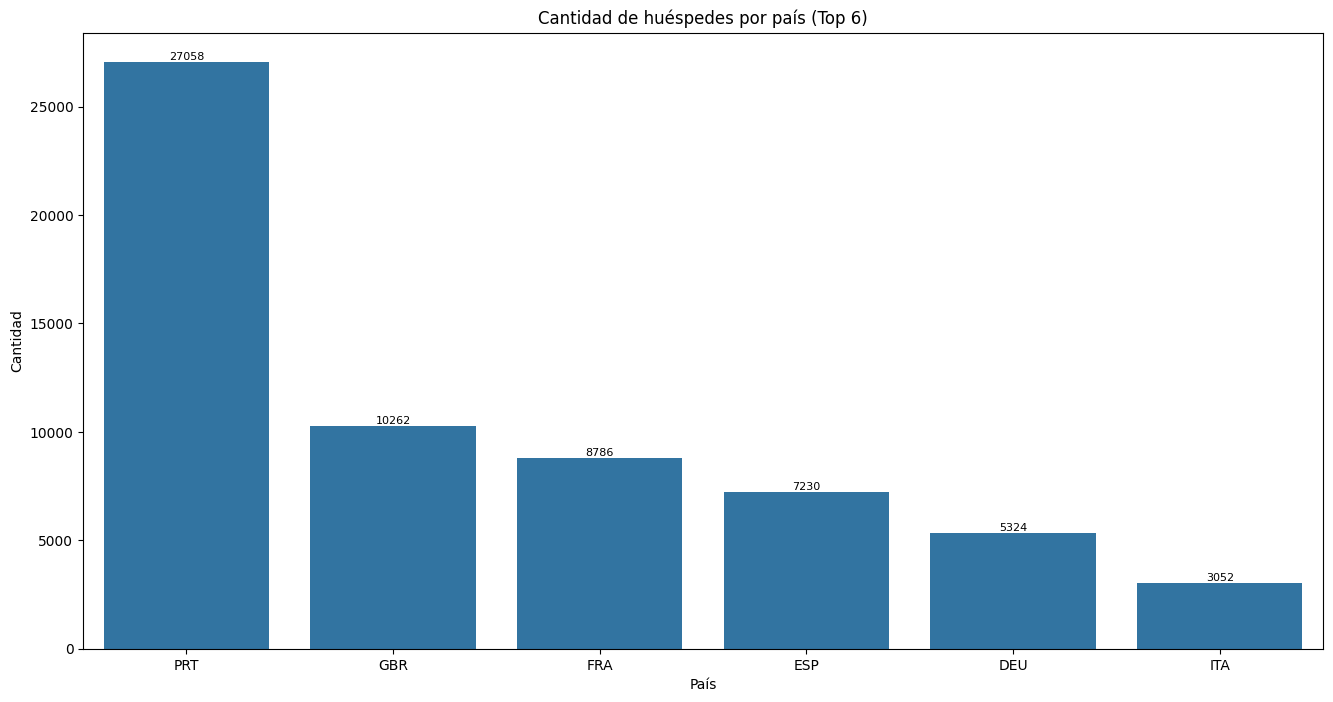

In [190]:
top_6_paises = df_imputed_IQR['huesped_pais'].value_counts().nlargest(6).index #cuento y me quedo con los 6 mas grandes
df_top6 = df_imputed_IQR[df_imputed_IQR['huesped_pais'].isin(top_6_paises)] #filtro mi dataset y creo el df_top6

plt.figure(figsize=(16,8))
ax = sns.countplot(x='huesped_pais', data=df_top6, order=top_6_paises)
plt.title('Cantidad de huéspedes por país (Top 6)')
plt.xlabel('País')
plt.ylabel('Cantidad')
# Agregar etiquetas arriba de cada barra
for p in ax.patches: #es la lista de barras dibujadas
    ax.annotate(f'{int(p.get_height())}',  #p.get_height() → da el valor (cantidad de huéspedes) ax.annotate() → escribe el número justo arriba de la barra.
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.show()


Portugal (PRT) es, por amplio margen, el país con más huéspedes (27.058), superando casi 4 veces al segundo lugar (Reino Unido, GBR).

Reino Unido (GBR) y Francia (FRA) están en segundo y tercer lugar con cifras relativamente cercanas (10.262 y 8.786 respectivamente).

España (ESP), Alemania (DEU) e Italia (ITA) muestran cantidades menores, con Italia como el país con menos huéspedes (3.052).

La distribución es muy desigual: Portugal representa la gran mayoría de las reservas dentro del top 6.

# De los 6 paises con mas reservas, cuantas cancelaciones y no shows tiene cada uno?


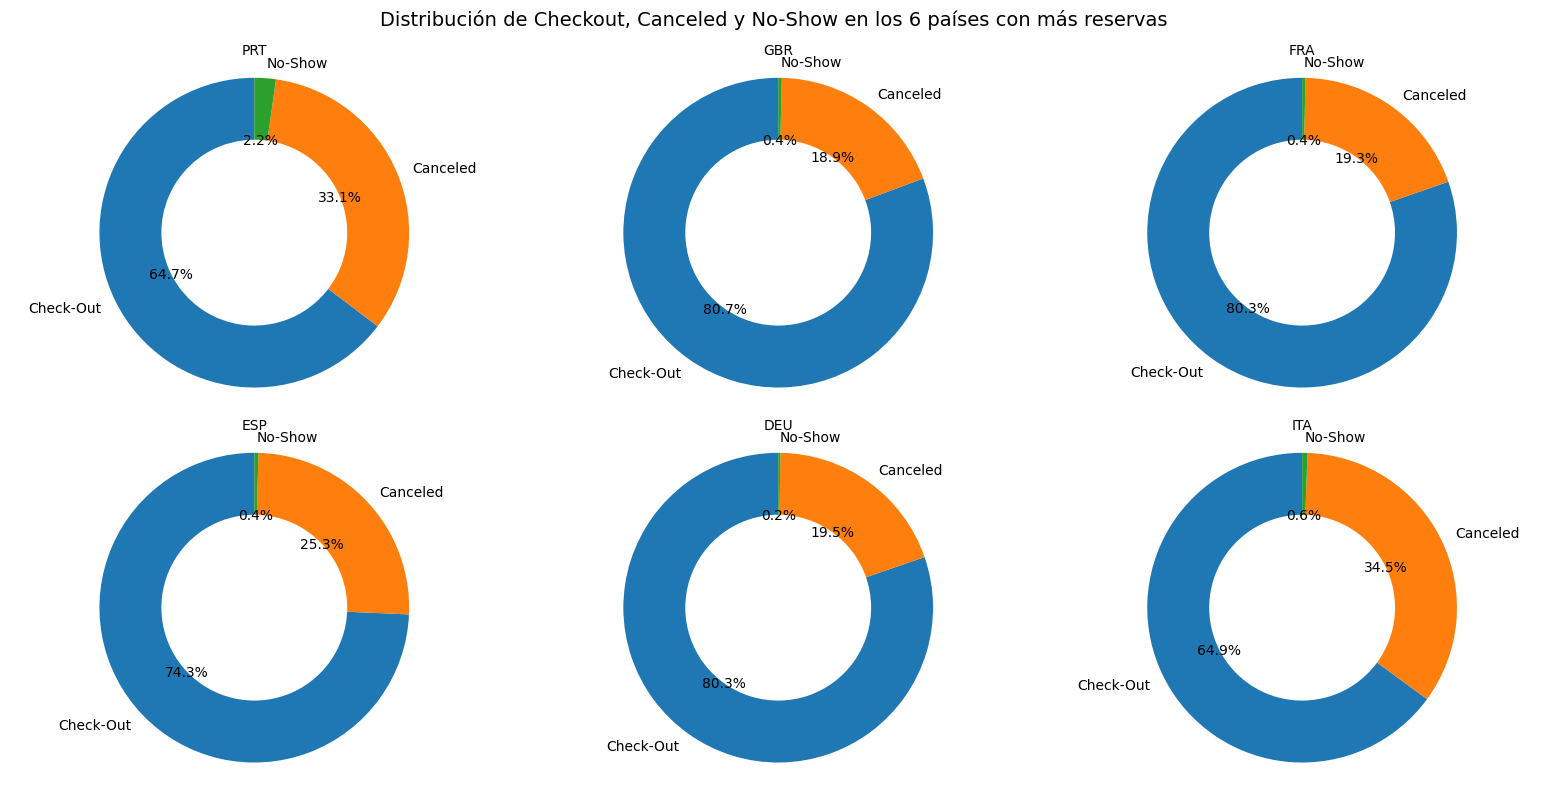

In [191]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))  # 2 filas x 3 columnas

# Flatten axes para iterar más fácil
axes = axes.flatten()

for ax, country in zip(axes, top_6_paises):
    df_country = df_top6[df_top6['huesped_pais'] == country]  # filtro datos de cada país
    estado_counts = df_country['reserva_estado'].value_counts()  # cuento los estados

    wedges, texts, autotexts = ax.pie(
        estado_counts,
        labels=estado_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4)
    )

    ax.set_title(country, fontsize=10)
    ax.axis('equal')  # para que sea circular

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.suptitle("Distribución de Checkout, Canceled y No-Show en los 6 países con más reservas", fontsize=14)
plt.tight_layout()
plt.show()

Portugal (PRT) es un caso atípico: más del 33.1% de sus reservas terminan en cancelación, mientras que el resto de los países tienen mayoría de check-outs.

Reino Unido (GBR), Francia (FRA) y Alemania (DEU) presentan una altísima proporción de check-outs (≈80% o más), lo que indica que la mayoría de sus reservas se concretan.

España (ESP) tiene un 25,3% de cancelaciones, más alto que la media, pero mucho menor que Portugal.

Italia (ITA) es el segundo país con mayor proporción de cancelaciones (34,5%), aunque tiene menos reservas totales.

No-Show es muy bajo en la mayoria de los países (<1%), por lo que no parece un problema relevante.

In [192]:
estado_recuento = df_top6['reserva_estado'].value_counts()
print(estado_recuento)

reserva_estado
Check-Out    44466
Canceled     16511
No-Show        735
Name: count, dtype: int64


#Sugerencias
Portugal es el país más relevante en volumen, pero su alta tasa de cancelaciones podría estar afectando indicadores de ocupación y requiere atención como analista de datos sugeriria una revision de la politica de cancelaciones para el mercado de Portugal.

El resto de los países tienen buen nivel de concreción (altas tasas de check-out), lo que sugiere huéspedes más confiables.

No-Show no es un problema significativo en ninguno de los países, ya que representa un porcentaje marginal.

#Cual es el mes con mayor cantidad de reservas?

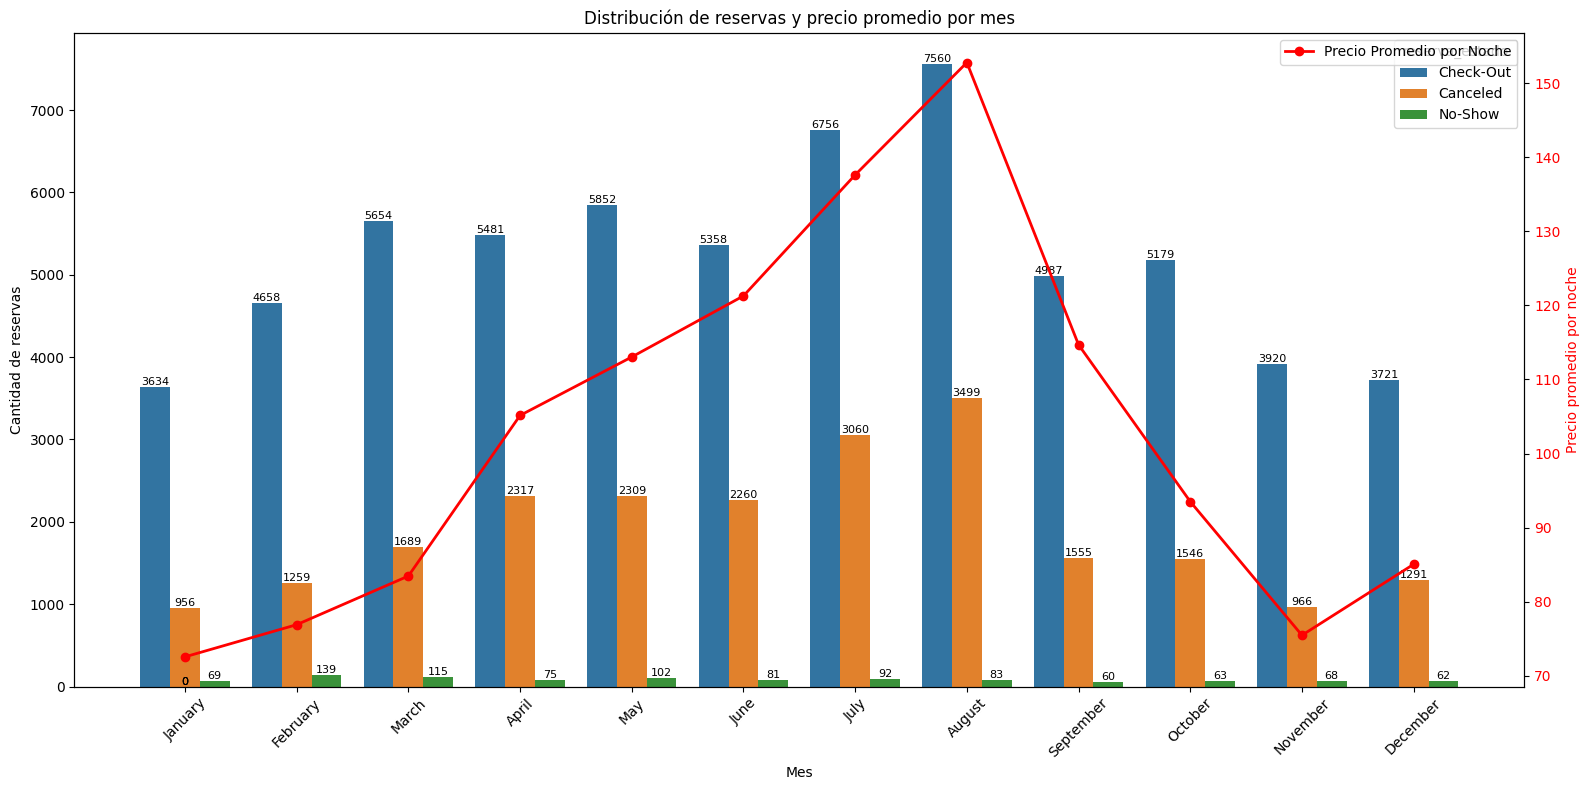

In [193]:
# --- Ordenar meses como categóricos ---
df_imputed_IQR['llegada_mes'] = pd.Categorical(
    df_imputed_IQR['llegada_mes'],
    categories=[
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ],
    ordered=True
)

# --- Agrupar para calcular el precio promedio por mes ---
precio_promedio_mes = (
    df_imputed_IQR.groupby('llegada_mes')['precio_promedio_noche']
    .mean()
    .reindex(df_imputed_IQR['llegada_mes'].cat.categories)  # respeta el orden
)

# --- Gráfico combinado ---
fig, ax1 = plt.subplots(figsize=(16, 8))

# Barras: cantidad de reservas por estado
sns.countplot(
    x='llegada_mes',
    data=df_imputed_IQR,
    order=df_imputed_IQR['llegada_mes'].cat.categories,
    hue='reserva_estado',
    ax=ax1
)

ax1.set_title('Distribución de reservas y precio promedio por mes')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Cantidad de reservas')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Etiquetas sobre las barras
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height)}',
                 (p.get_x() + p.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=8)

# Crear segundo eje Y para el precio
ax2 = ax1.twinx()
ax2.plot(
    precio_promedio_mes.index,
    precio_promedio_mes.values,
    color='red',
    marker='o',
    linewidth=2,
    label='Precio Promedio por Noche'
)
ax2.set_ylabel('Precio promedio por noche', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Agregar leyenda de la línea
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


•	La mayor cantidad de reservas totales ocurre en Julio y Agosto, lo que es típico de la temporada de verano en el hemisferio norte. Agosto muestra el pico absoluto de la demanda.
•	La demanda es relativamente estable y más baja de Noviembre a Abril, con un repunte en el primer trimestre (Marzo/Abril).
•	Enero y Febrero son meses con demanda alta, pero no tanto como el verano, lo que sugiere que son populares para el turismo de invierno o escapadas de principio de año.

•	El precio promedio por noche sigue una tendencia casi idéntica a la cantidad de reservas. El precio más bajo se observa en Enero (aprox. 75) y alcanza su pico más alto en Agosto (cercano a 140).

  •	Esto confirma que el hotel está aplicando una estrategia de precios dinámica: los precios suben en respuesta a la mayor demanda.

•	El precio experimenta una caída muy abrupta después de Agosto, con un descenso significativo en Septiembre y Octubre, a pesar de que la cantidad de reservas no cae tan drásticamente. Esto podría indicar el fin de la temporada turística principal.

•	La cantidad absoluta de cancelaciones es consistentemente alta en los meses de alta demanda y alto precio (Julio y Agosto).
•	Julio (3060): Alta cancelación.

•	Agosto (3499): El mes con la mayor cantidad absoluta de cancelaciones de todo el año, lo cual es un gran problema de pérdida de ingresos.
•	La demanda y el precio son máximos en Agosto, pero la proporción de cancelación (Canceladas / Total Reservas) parece ser significativamente alta.

Esto sugiere que:

1.	Las reservas de Agosto se hicieron con mucha anticipación (lo que aumenta la probabilidad de cambio de planes).

2.	El alto precio puede llevar a los clientes a buscar alternativas más baratas antes de la llegada.

•	En general, el número de No-Show es muy bajo en comparación con las cancelaciones y los Check-Outs (casi siempre por debajo de 150). Son relativamente uniformes a lo largo del año. No muestran la estacionalidad extrema de las cancelaciones, lo que podría sugerir que no están fuertemente ligados al tipo de cliente de temporada alta, sino a una estrategia de reserva (como tarifas no reembolsables o pagos muy bajos).


#En que semana del anio hay mas reservas con menores?

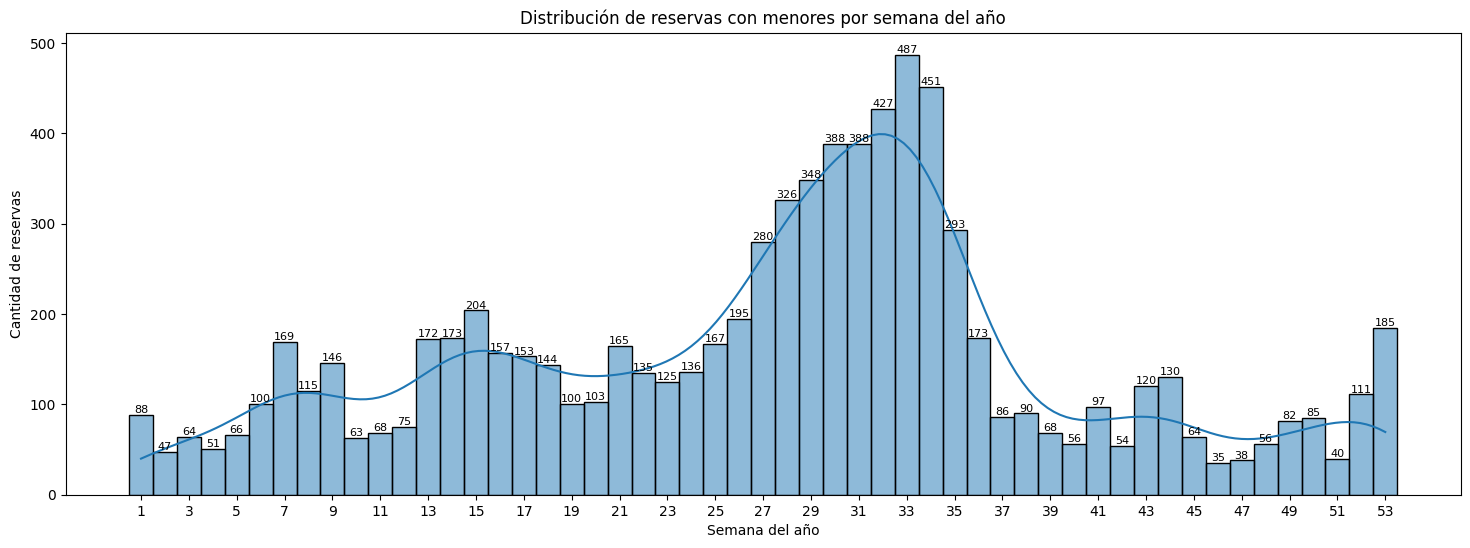

In [194]:
# Filtro reservas con menores
df_menores = df_imputed_IQR[df_imputed_IQR['menores'] > 0]

plt.figure(figsize=(18,6))
ax = sns.histplot(df_menores['llegada_semana'], bins=30, discrete=True, kde=True)# discrete=True: una barra por semana

plt.title('Distribución de reservas con menores por semana del año')
plt.xlabel('Semana del año')
plt.ylabel('Cantidad de reservas')

# Mostrar eje X de 2 en 2
xticks = range(int(df_menores['llegada_semana'].min()),
               int(df_menores['llegada_semana'].max())+1,2)
ax.set_xticks(xticks)

# Agregar etiqueta a cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # solo anotar si hay datos
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=8)

plt.show()


Hay una clara concentración de reservas familiares entre las semanas 27 y 35 (julio y agosto), coincidiendo con vacaciones escolares en muchos países europeos.

Después de la semana 35, las reservas con menores caen de manera abrupta, marcando el fin de la temporada alta.

Se observa un pequeño repunte en la semana 52, posiblemente asociado a vacaciones de Navidad y fin de año.

#Sugerencias estrategicas

**Optimizar tarifas en temporada alta**

Aplicar tarifas dinamicas en julio y agosto para maximizar el ingreso por habitación.

Considerar mínimo de noches en reservas durante semanas de mayor ocupación para mejorar el promedio de precio por noche.

**Mejorar la gestión de cancelaciones**

Implementar tarifas no reembolsables o con penalidad progresiva en los meses de mayor demanda (abril-agosto).

Ofrecer beneficios por reserva anticipada para reducir cancelaciones de último momento.

**Potenciar la oferta para familias**

Diseñar paquetes familiares (hospedaje + actividades + alimentación) en semanas 27–35.

Comunicar estos paquetes con antelación (campañas en Q1/Q2) para captar el público que planifica vacaciones.

**Desestacionalizar la demanda**

Lanzar promociones especiales en temporada baja (enero, noviembre, diciembre pre-fiestas) para mantener ocupación estable.

Promover eventos corporativos, retiros o escapadas románticas en los meses de menor ocupación.

#Cuanto es el precio promedio por noche de cada tipo de cuarto?

  cuarto_tipo_reserva  precio_promedio_noche
0                   A              92.365372
1                   B              93.164562
2                   C             162.153487
3                   D             121.652623
4                   E             126.168335
5                   F             170.083507
6                   G             179.988386
7                   H             189.171531
8                   L             124.666667
9                   P              95.000000


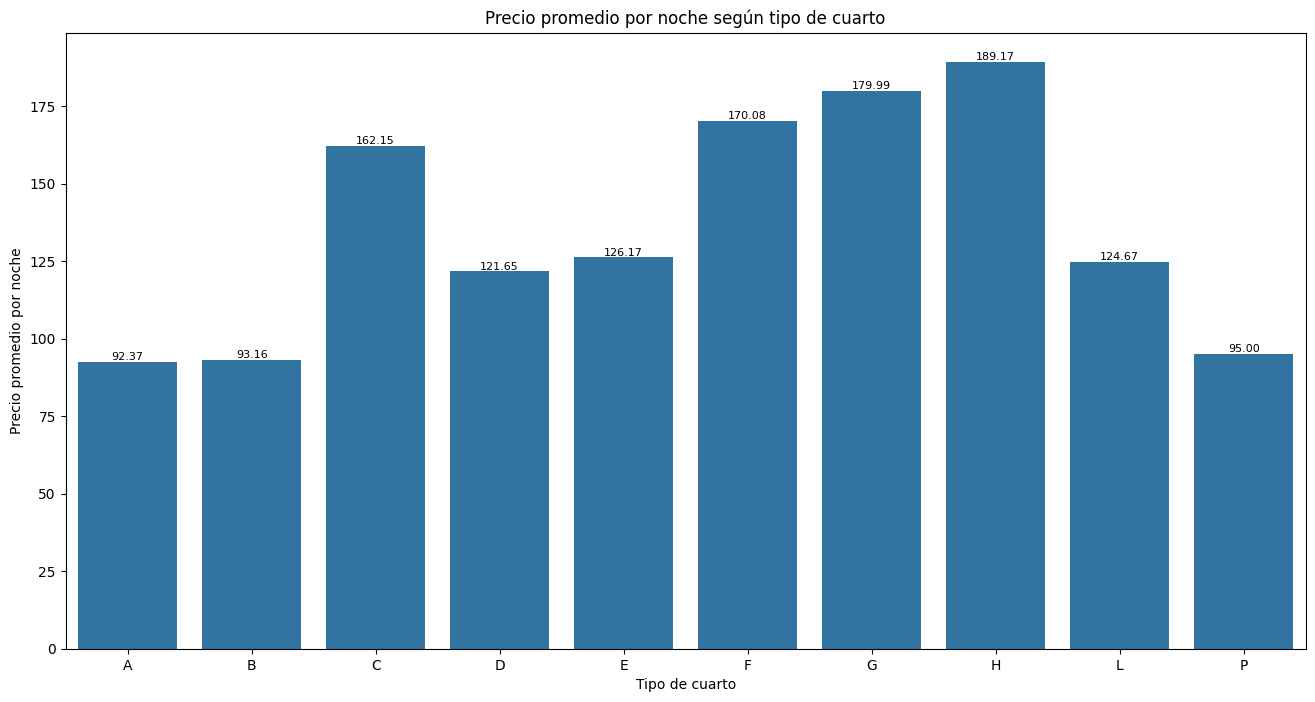

In [195]:
# Calcular promedio y convertir en DataFrame
df_imputed = pd.DataFrame(df_imputed)
df_promedios = df_imputed.groupby('cuarto_tipo_reserva')['precio_promedio_noche'].mean().reset_index()

print(df_promedios)

plt.figure(figsize=(16,8))
ax = sns.barplot(
    data=df_promedios,
    x='cuarto_tipo_reserva',           # eje X: tipo de cuarto
    y='precio_promedio_noche'          # eje Y: promedio
)

plt.title('Precio promedio por noche según tipo de cuarto')
plt.ylabel('Precio promedio por noche')
plt.xlabel('Tipo de cuarto')

#números sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',  # mostrar con 2 decimales
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.show()

#Analisis de correlacion entre las variables:


*   Cancelacion
*   Anticipacion de la reserva
*  Requerimientos especiales
*  Tipo de deposito



In [196]:
df_imputed_IQR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86476 entries, 0 to 115983
Data columns (total 69 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   cancelada                          86476 non-null  int64   
 1   reserva_anticipacion_dias          86476 non-null  int64   
 2   llegada_anio                       86476 non-null  int64   
 3   llegada_mes                        86476 non-null  category
 4   llegada_semana                     86476 non-null  int64   
 5   llegada_dia                        86476 non-null  int64   
 6   estadia_fines_de_semana_noches     86476 non-null  int64   
 7   estadia_lun_a_vie_noches           86476 non-null  int64   
 8   adultos                            86476 non-null  int64   
 9   menores                            86476 non-null  float64 
 10  bebes                              86476 non-null  int64   
 11  huesped_pais                       86476 non-

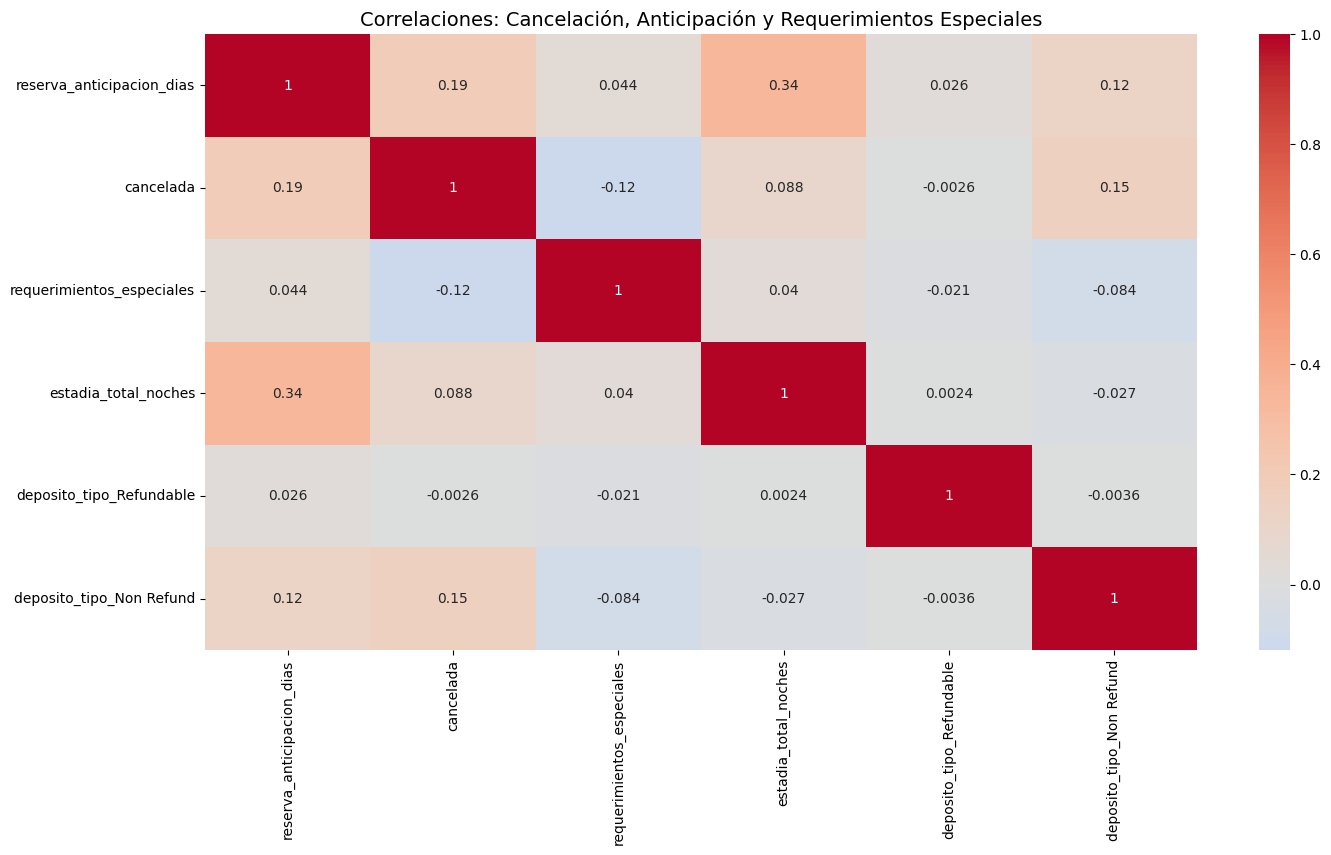

In [197]:
# Estadía total = estadia de lun a viernes + estadia en fines de semana
df_imputed['estadia_total_noches'] = (
    df_imputed['estadia_fines_de_semana_noches'] + df_imputed['estadia_lun_a_vie_noches']
)

# Seleccionar solo las columnas de interés
cols_interes = ['reserva_anticipacion_dias', 'cancelada',
                'requerimientos_especiales', 'estadia_total_noches', 'deposito_tipo_Refundable','deposito_tipo_Non Refund']

df_corr = df_imputed_IQR[cols_interes].corr()

# Graficar heatmap
plt.figure(figsize=(16,8))
sns.heatmap(df_corr, annot=True,  cmap= 'coolwarm' , center=0)
plt.title('Correlaciones: Cancelación, Anticipación y Requerimientos Especiales' , fontsize=14)
plt.show()


#Hipotesis:

1. Relación entre reserva_anticipacion_dias y estadia_total_noches

  •	Correlación: 0.34 (positiva moderada)
Los huéspedes que reservan con mayor anticipación tienden a quedarse más noches. Esto sugiere que las estadías más largas suelen ser planificadas con tiempo, posiblemente por viajeros de vacaciones o grupos familiares.

2. Anticipación y cancelación

  •	Correlación: 0.19 (positiva débil)
Existe una leve tendencia a que las reservas hechas con mucha anticipación tengan una mayor probabilidad de cancelarse. Quienes planifican con mucha antelación pueden estar más propensos a cambiar sus planes o modificar la fecha del viaje.

3. Requerimientos especiales y cancelación

  •	Correlación: -0.12 (débil y negativa)
Las reservas con requerimientos especiales se cancelan con menos frecuencia. Esto puede indicar un mayor compromiso del huésped cuando su reserva responde a necesidades específicas.

4. Cancelación y tipo de depósito (Non Refundable)

  •	Correlación: 0.15 (positiva débil)
Las reservas con depósito no reembolsable presentan una leve tendencia a no ser canceladas, lo cual es consistente con las políticas más restrictivas que desalientan cancelaciones.

#Conclusión general:

•	Las variables reserva_anticipacion_dias, estadia_total_noches y tipo de depósito son las que más relación muestran con la cancelación.

•	Las cancelaciones tienden a ocurrir con mayor frecuencia en reservas anticipadas y con depósitos flexibles o sin penalización.

•	Los huéspedes con requerimientos especiales representan un grupo más estable y comprometido.


#Codificacion de la variable reserva_estado

In [198]:
# Transformar target a numérico
estado_map = {
    'Check-Out': 0,    # La reserva se completó
    'Canceled': 1,     # La reserva fue cancelad
    'No-Show': 2       # El huésped no se presentó
}

df_imputed_IQR['reserva_estado_codificada'] = df_imputed_IQR['reserva_estado'].map(estado_map)

y = df_imputed_IQR['reserva_estado_codificada']

print(y.value_counts())

reserva_estado_codificada
0    62760
1    22707
2     1009
Name: count, dtype: int64


# Seleccion de características

In [199]:
columnas_a_excluir = [
    'llegada_mes',                # Ya la codificamos numéricamente
    'reserva_ultima_actulizacion',# Demasiado específica o no predictora (fecha del evento)
    'reserva_estado_codificada',  # Variable objetivo codificada
    'reserva_estado',            # Variable objetivo original
    'agente',                     # Eliminar columnas con muchos nulos
    'compania',                   # Eliminar columnas con muchos nulos
    'reserva_canal',               # No usada en este modelo
    'huesped_pais'               # Contiene strings, no utilizada en este modelo
]

In [200]:
#Separamos los datos de entrada de la salida
X = df_imputed_IQR.drop(columns=columnas_a_excluir, axis=1) #Elimino de mi dataset la variable a predecir
y = df_imputed_IQR['reserva_estado_codificada'] #Defino el Target

#SelectKBest, f_classif

In [201]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif # Added this import

# División Estratificada (20% para prueba)
# stratify=y asegura que la proporción de 0, 1 y 2 sea la misma en X_train y X_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarización de las Características
scaler = StandardScaler()

# 1. Entrenar el escalador SÓLO con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# 2. Aplicar la transformación a los conjuntos de prueba
X_test_scaled = scaler.transform(X_test)

print("Datos listos para el entrenamiento: escalados y divididos.")

# Define el número de características que quieres seleccionar
k_best_features = 15

# Inicializa el selector usando f_classif
selector = SelectKBest(score_func=f_classif, k=k_best_features)

# Aplica la selección solo a los datos de entrenamiento
X_train_reduced = selector.fit_transform(X_train, y_train)
X_test_reduced = selector.transform(X_test)

# Identifica cuáles son esas K mejores características
selected_features = X.columns[selector.get_support()]

print(f"Las {k_best_features} características seleccionadas son:")
print(selected_features.tolist())

Datos listos para el entrenamiento: escalados y divididos.
Las 15 características seleccionadas son:
['cancelada', 'reserva_anticipacion_dias', 'llegada_anio', 'adultos', 'reserva_cambios', 'precio_promedio_noche', 'estacionamiento', 'requerimientos_especiales', 'segmento_de_mercado_Direct', 'segmento_de_mercado_Offline TA/TO', 'segmento_de_mercado_Online TA', 'deposito_tipo_No Deposit', 'deposito_tipo_Non Refund', 'reserva_tipo_Transient', 'reserva_tipo_Transient-Party']


#Modelo de Mahcine Learning para Prediccion

In [202]:
!pip install catboost

In [203]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [204]:
# Transformar target a numérico
estado_map = {
    'Check-Out': 0,    # La reserva se completó
    'Canceled': 1,     # La reserva fue cancelada
    'No-Show': 2       # El huésped no se presentó
}

df_imputed_IQR['reserva_estado_codificada'] = df_imputed_IQR['reserva_estado'].map(estado_map)

# Seleccionar features basado en el análisis de correlación
best_features = ['cancelada',
                 'reserva_anticipacion_dias',
                 'llegada_anio',
                 'adultos',
                 'reserva_cambios',
                 'precio_promedio_noche',
                 'estacionamiento',
                 'requerimientos_especiales',
                 'segmento_de_mercado_Direct',
                 'segmento_de_mercado_Offline TA/TO',
                 'segmento_de_mercado_Online TA',
                 'deposito_tipo_No Deposit',
                 'deposito_tipo_Non Refund',
                 'reserva_tipo_Transient',
                 'reserva_tipo_Transient-Party']


In [205]:
X = df_imputed_IQR[best_features].copy()
y = df_imputed_IQR['reserva_estado_codificada']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset: {X.shape[0]} muestras, {X.shape[1]} features")
print(f"Distribución target: {y.value_counts().to_dict()}")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

Dataset: 86476 muestras, 15 features
Distribución target: {0: 62760, 1: 22707, 2: 1009}
Train: 69180 muestras
Test: 17296 muestras


In [206]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=False, iterations=100)
}

In [207]:
# Entrenar y evaluar modelos
print("ENTRENANDO Y EVALUANDO MODELOS")

results = {}
predictions = {}
y_pred_proba_dict = {}

for name, model in models.items():
    print(f"\n Entrenando {name}...")

    # Usar datos escalados para modelos que lo requieren
    if name in ['Logistic Regression', 'XGBoost', 'LightGBM']:
        print(f"Generando data scaled para : {name}")
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        print(f"Generando data para : {name}")
        # For models that don't require scaling, ensure they get the features selected by SelectKBest if applicable
        if 'X_train_reduced' in locals() and name in ['Decision Tree', 'Random Forest', 'CatBoost']:
            X_tr, X_te = X_train_reduced, X_test_reduced
        else:
            X_tr, X_te = X_train, X_test


    # Entrenar modelo
    model.fit(X_tr, y_train)

    # Predecir
    y_pred = model.predict(X_te)
    # Predict probabilities for AUC - handle multiclass
    y_pred_proba = model.predict_proba(X_te)


    # Calcular métricas - Specify average for multiclass
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0) # Use weighted average for multiclass
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)    # Use weighted average for multiclass
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)        # Use weighted average for multiclass
    # Calculate AUC for multiclass using 'ovr'
    model_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')


    # Cross validation
    # Use appropriate data for CV - scaled if needed, reduced if SelectKBest was applied
    if name in ['Logistic Regression', 'XGBoost', 'LightGBM']:
         cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    elif 'X_train_reduced' in locals() and name in ['Decision Tree', 'Random Forest', 'CatBoost']:
         cv_scores = cross_val_score(model, X_train_reduced, y_train, cv=5, scoring='accuracy')
    else:
         cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')


    # Guardar resultados
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': model_auc, # Use model_auc here
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }

    predictions[name] = y_pred
    y_pred_proba_dict[name] = y_pred_proba

    print(f"{name} completado - Accuracy: {accuracy:.3f}")

# Mostrar resultados comparativos
print(" RESULTADOS COMPARATIVOS (CON CATBOOST)")

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df_sorted = results_df.sort_values('Accuracy', ascending=False)

ENTRENANDO Y EVALUANDO MODELOS

 Entrenando Logistic Regression...
Generando data scaled para : Logistic Regression
Logistic Regression completado - Accuracy: 0.988

 Entrenando Decision Tree...
Generando data para : Decision Tree
Decision Tree completado - Accuracy: 0.988

 Entrenando Random Forest...
Generando data para : Random Forest
Random Forest completado - Accuracy: 0.988

 Entrenando XGBoost...
Generando data scaled para : XGBoost
XGBoost completado - Accuracy: 0.988

 Entrenando LightGBM...
Generando data scaled para : LightGBM
LightGBM completado - Accuracy: 0.988

 Entrenando CatBoost...
Generando data para : CatBoost
CatBoost completado - Accuracy: 0.988
 RESULTADOS COMPARATIVOS (CON CATBOOST)


In [208]:
results_df_sorted

,Accuracy,Precision,Recall,F1-Score,AUC,CV Mean,CV Std
Logistic Regression,0.9883,0.9771,0.9883,0.9826,0.9795,0.9883,0.0001
Decision Tree,0.9883,0.9771,0.9883,0.9826,0.9760,0.9883,0.0001
Random Forest,0.9881,0.9837,0.9881,0.9846,0.9648,0.9872,0.0003
XGBoost,0.9880,0.9826,0.9880,0.9837,0.9823,0.9881,0.0005
LightGBM,0.9880,0.9829,0.9880,0.9839,0.9826,0.9879,0.0003
CatBoost,0.9875,0.9812,0.9875,0.9833,0.9829,0.9881,0.0002


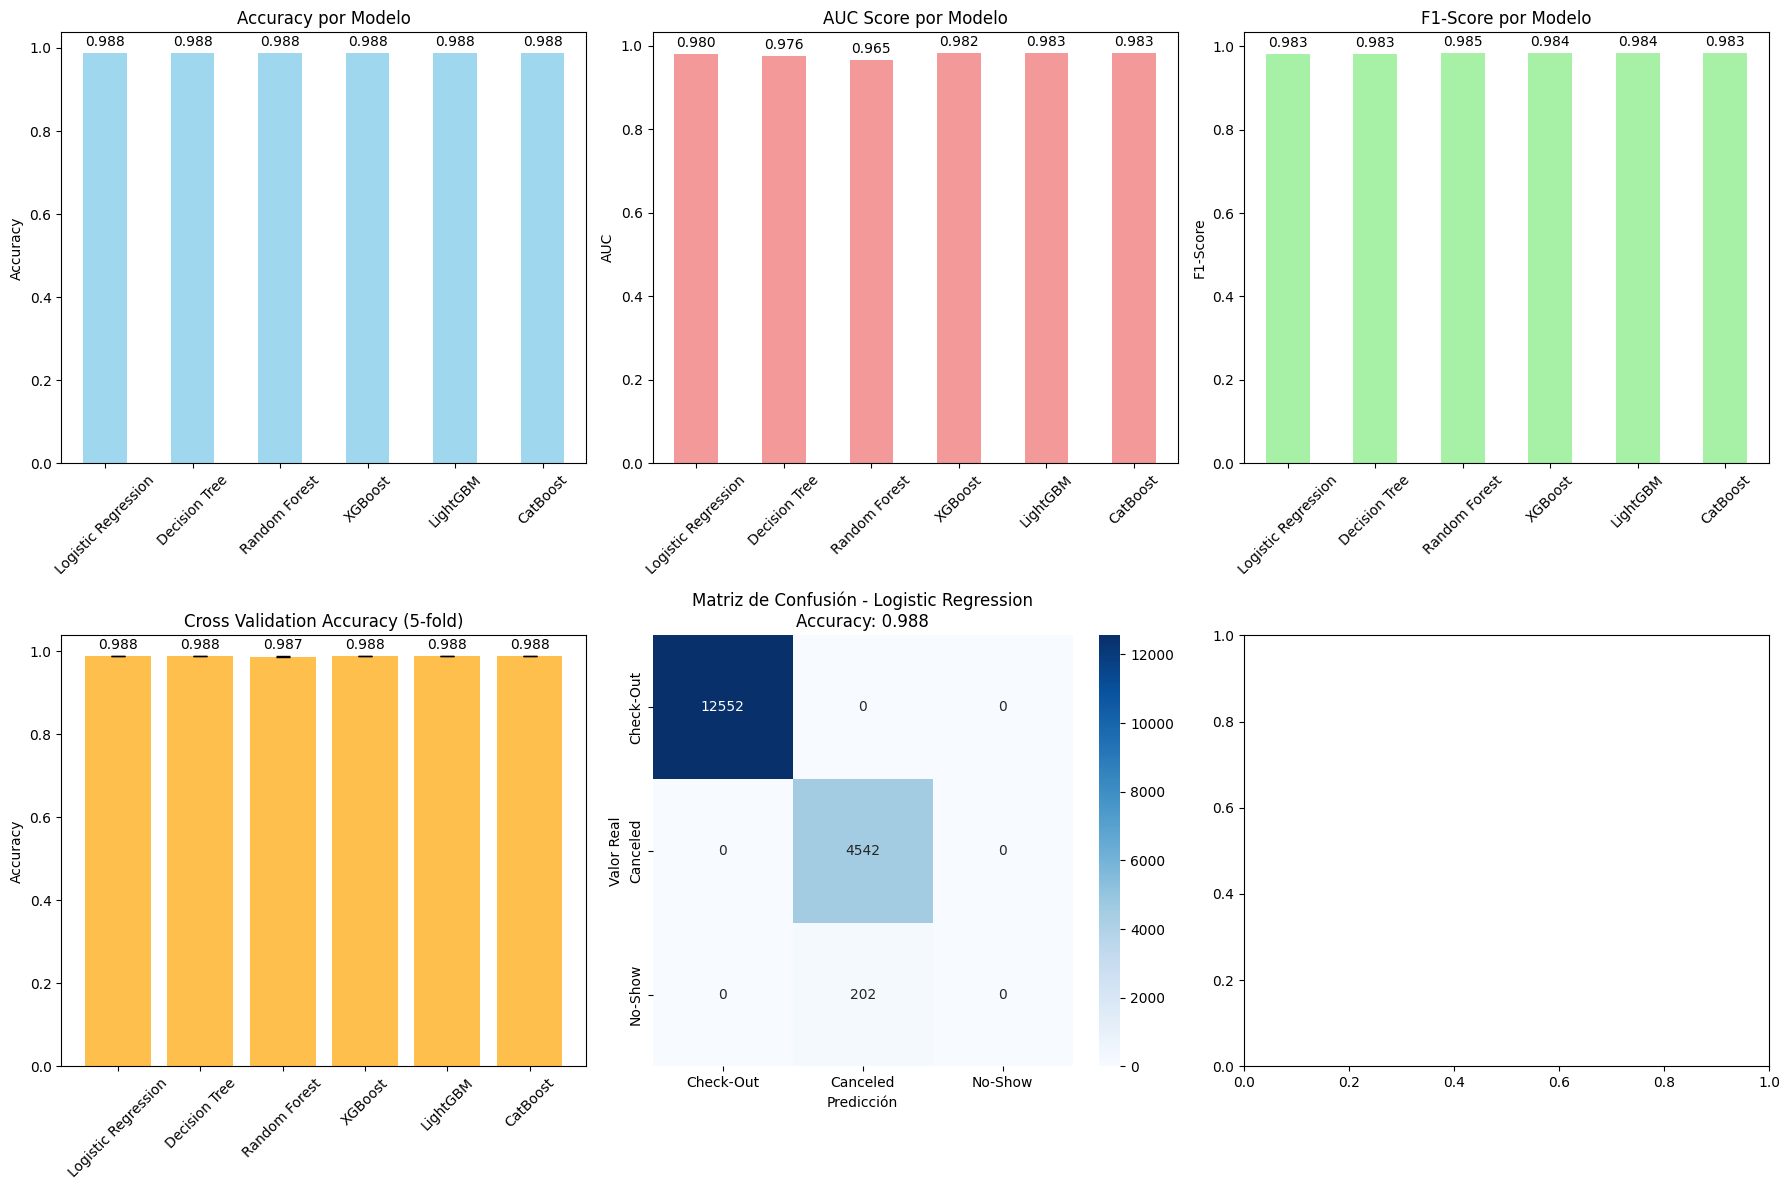

In [209]:
# Visualización de métricas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Gráfico 1: Accuracy
results_df_sorted['Accuracy'].plot(kind='bar', ax=axes[0,0], color='skyblue', alpha=0.8)
axes[0,0].set_title('Accuracy por Modelo')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df_sorted['Accuracy']):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Gráfico 2: AUC
results_df_sorted['AUC'].plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
axes[0,1].set_title('AUC Score por Modelo')
axes[0,1].set_ylabel('AUC')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df_sorted['AUC']):
    axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Gráfico 3: F1-Score
results_df_sorted['F1-Score'].plot(kind='bar', ax=axes[0,2], color='lightgreen', alpha=0.8)
axes[0,2].set_title('F1-Score por Modelo')
axes[0,2].set_ylabel('F1-Score')
axes[0,2].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df_sorted['F1-Score']):
    axes[0,2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Gráfico 4: Cross Validation
cv_means = results_df_sorted['CV Mean']
cv_stds = results_df_sorted['CV Std']
axes[1,0].bar(cv_means.index, cv_means.values, yerr=cv_stds.values,
             capsize=5, alpha=0.7, color='orange')
axes[1,0].set_title('Cross Validation Accuracy (5-fold)')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cv_means.values):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Gráfico 5: Matriz de confusión del mejor modelo
best_model_name = results_df_sorted['Accuracy'].idxmax()
best_y_pred = predictions[best_model_name]
#cm = confusion_matrix(y_test, best_y_pred)

# --- Calcular matriz de confusión ---
# Use unique values from y_test as labels
labels = np.unique(y_test)
cm = confusion_matrix(y_test, best_y_pred, labels=labels)

# Get the class labels based on the numeric codes
class_labels = {0: 'Check-Out', 1: 'Canceled', 2: 'No-Show'}
tick_labels = [class_labels[label] for label in labels]


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1],
            xticklabels=tick_labels,
            yticklabels=tick_labels)

axes[1,1].set_title(f'Matriz de Confusión - {best_model_name}\nAccuracy: {results_df_sorted.loc[best_model_name, "Accuracy"]:.3f}')
axes[1,1].set_xlabel('Predicción')
axes[1,1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

CURVAS ROC - TODOS LOS MODELOS (One-vs-Rest)


TypeError: 'numpy.float64' object is not callable

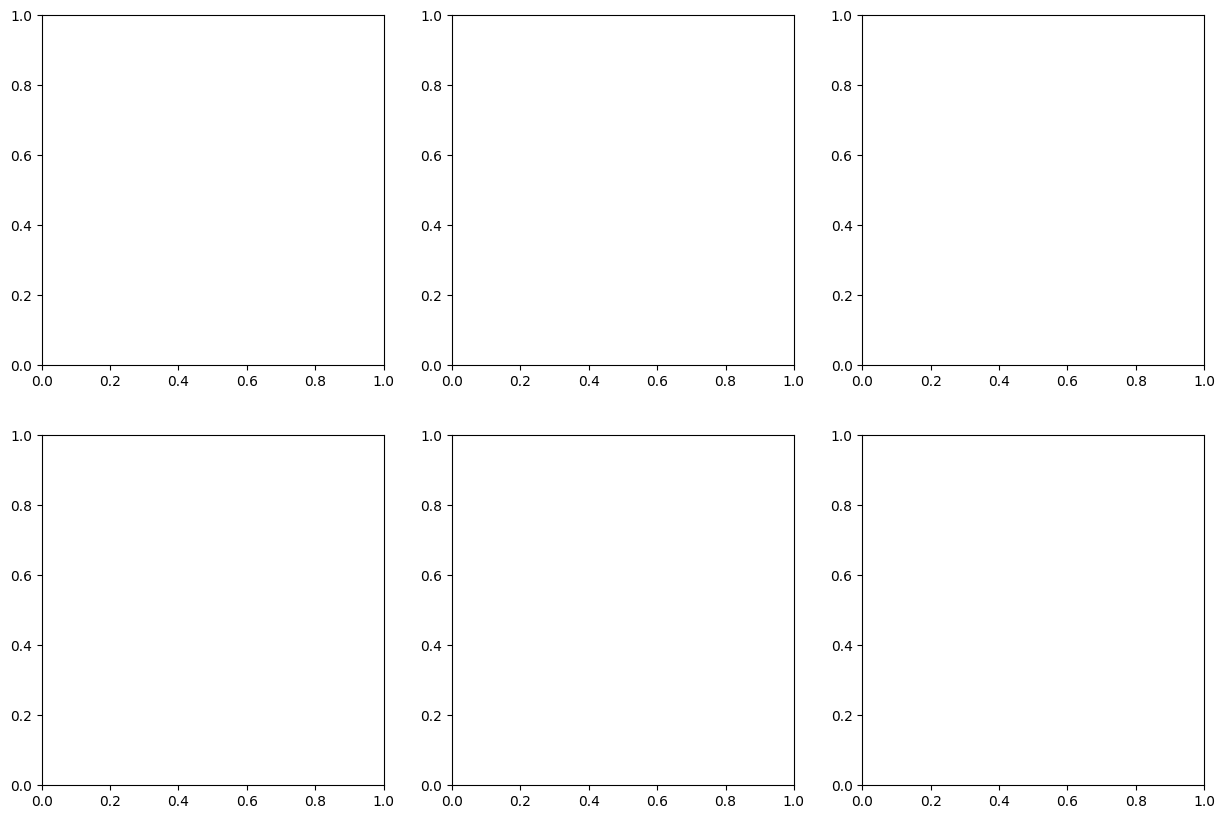

In [210]:
# Curvas ROC en subplots individuales
print("CURVAS ROC - TODOS LOS MODELOS (One-vs-Rest)")

# Calcular el número de filas y columnas para los subplots
n_models = len(models)
n_cols = 3  # Puedes ajustar este número según prefieras
n_rows = (n_models + n_cols - 1) // n_cols  # División redondeada hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]  # Aplanar el array de axes

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
class_names = np.unique(y_test) # Get the unique class names/labels

for i, (name, color) in enumerate(zip(models.keys(), colors)):
    if i < len(axes):  # Asegurarse de que no excedemos el número de subplots
        ax = axes[i]
        y_pred_proba = y_pred_proba_dict[name]

        # Plot ROC curve for each class (One-vs-Rest)
        for j in range(len(class_names)):
            # Binarize the true labels for the current class
            y_true_class = (y_test == class_names[j]).astype(int)

            # Get the predicted probabilities for the current class
            # Ensure y_pred_proba has the correct shape for the model
            if y_pred_proba.ndim == 2:
                 y_score_class = y_pred_proba[:, j]
            elif y_pred_proba.ndim == 1 and len(class_names) == 2: # Handle binary case if necessary
                 y_score_class = y_pred_proba # For binary, predict_proba returns shape (n_samples,) for the positive class
                 if class_names[j] == 0: # If plotting for class 0 in a binary case, use 1 - probabilities
                      y_score_class = 1 - y_score_class
            else:
                 # Handle unexpected dimensions or non-binary cases not covered
                 print(f"Warning: Could not plot ROC for {name}, unexpected predict_proba shape: {y_pred_proba.shape}")
                 continue


            # Calculate ROC curve
            fpr, tpr, _ = roc_curve(y_true_class, y_score_class)
            roc_auc = auc(fpr, tpr)

            # Plot the ROC curve for the current class on the subplot
            ax.plot(fpr, tpr, label=f'Class {class_names[j]} (AUC = {roc_auc:.3f})',
                    linewidth=1.5) # Reduced linewidth for clarity with multiple curves


        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5,
                    label='Clasificador Aleatorio', linewidth=1) # Reduced linewidth

        # Configurar el subplot individual
        ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=10)
        ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=10)
        ax.set_title(f'Curva ROC - {name}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='lower right') # Adjusted legend font size and location
        ax.grid(alpha=0.3)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])

# Ocultar los subplots vacíos si los hay
for i in range(n_models, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#IMPORTANCIA DE FEATURES - COMPARATIVO
print("IMPORTANCIA DE FEATURES - COMPARATIVO")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
all_models = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Logistic Regression']

for i, model_name in enumerate(all_models):
    model = models[model_name]

    # Determinar si es modelo ensemble (usa feature_importances_) o lineal (usa coef_)
    if hasattr(model, 'feature_importances_'):
        # Para modelos ensemble
        feature_importance = pd.DataFrame({
            'feature': best_features,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=True)

        title = f'Feature Importance - {model_name}'
        xlabel = 'Importancia'

    elif hasattr(model, 'coef_'):
        # Para Logistic Regression - usar valores absolutos de coeficientes
        importance_values = np.abs(model.coef_[0])
        feature_importance = pd.DataFrame({
            'feature': best_features,
            'importance': importance_values
        }).sort_values('importance', ascending=True)

        title = f'Coeficientes (abs) - {model_name}'
        xlabel = '|Coeficiente|'

    # Crear el gráfico
    row, col = i//3, i%3
    ax = axes[row, col]
    bars = ax.barh(feature_importance['feature'], feature_importance['importance'],
                  color=plt.cm.viridis(np.linspace(0, 1, len(best_features))))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)

    # Añadir valores en las barras
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
               f'{width:.3f}', ha='left', va='center', fontsize=8)

# Feature importance promedio (solo para modelos con feature_importances_)
ensemble_models = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
avg_importance = pd.DataFrame({'feature': best_features})

for model_name in all_models:
    model = models[model_name]

    if hasattr(model, 'feature_importances_'):
        # Para modelos ensemble
        avg_importance[model_name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # Para Logistic Regression - normalizar coeficientes para comparar
        coef_abs = np.abs(model.coef_[0])
        # Normalizar para que sumen 1 (similar a feature_importances_)
        coef_normalized = coef_abs / coef_abs.sum()
        avg_importance[model_name] = coef_normalized

# Calcular promedio de todos los modelos
avg_importance['Average'] = avg_importance[all_models].mean(axis=1)
avg_importance = avg_importance.sort_values('Average', ascending=True)

# Gráfico de promedio
axes[1, 2].barh(avg_importance['feature'], avg_importance['Average'],
               color=plt.cm.plasma(np.linspace(0, 1, len(best_features))))
axes[1, 2].set_title('Importancia Promedio - Todos los Modelos', fontweight='bold')
axes[1, 2].set_xlabel('Importancia Promedio')

# Añadir valores en las barras del promedio
bars_avg = axes[1, 2].containers[0]
for bar in bars_avg:
    width = bar.get_width()
    axes[1, 2].text(width + 0.001, bar.get_y() + bar.get_height()/2,
                   f'{width:.3f}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Regresion logistica

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay, accuracy_score
)

# --- 1. ESCALADO DE VARIABLES ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- 3. CONFIGURACIÓN DEL MODELO Y GRIDSEARCH ---
grid_log_reg = {
    "penalty": ["l2"],         # solo una regularización
    "C": [0.1, 1.0, 5.0],      # 3 valores razonables
    "max_iter": [200],         # suficiente para converger
    "solver": ["liblinear"]
}

log_reg = LogisticRegression()
log_reg_cv = GridSearchCV(log_reg, grid_log_reg, cv=3, scoring="accuracy")

In [ ]:
# --- 4. ENTRENAMIENTO DEL MODELO ---
log_reg_cv.fit(X_train_scaled, y_train)

In [ ]:
# --- 5. PREDICCIONES ---
y_train_pred = log_reg_cv.predict(X_train_scaled)
y_test_pred = log_reg_cv.predict(X_test_scaled)

In [ ]:
# --- 6. RESULTADOS BÁSICOS ---
print("Mejores hiperparámetros:", log_reg_cv.best_params_)
print("Mejor score en validación cruzada:", log_reg_cv.best_score_)
print("\nAccuracy en entrenamiento:", accuracy_score(y_train, y_train_pred))
print("Accuracy en test:", accuracy_score(y_test, y_test_pred))

In [ ]:
# --- 7. MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusión - Regresión Logística (Multiclase)")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

In [ ]:
# --- 8. REPORTE DE CLASIFICACIÓN ---
print("\nReporte de Clasificación:\n")
print(classification_report(y_test, y_test_pred))

In [ ]:
# --- 9. CURVA ROC Y AUC MULTICLASE ---
# Calcula probabilidades por clase
y_score = log_reg_cv.predict_proba(X_test_scaled)

In [ ]:
# Calcular AUC promedio (One-vs-Rest)
auc_macro = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
print(f"\nAUC promedio (One-vs-Rest): {auc_macro:.3f}")

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Assume log_reg_cv is your fitted multiclass model
# Assume X_test_scaled and y_test are your test data
# y_test should contain the true class labels (0, 1, 2, ...)

# Get predicted probabilities for each class
y_score = log_reg_cv.predict_proba(X_test_scaled)

# Get the unique classes
classes = np.unique(y_test)

# Set up the plot
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Chance') # Plot the random guess line

# Plot ROC curve for each class (One-vs-Rest)
for i in range(len(classes)):
    # Binarize the true labels for the current class
    y_true_class = (y_test == classes[i]).astype(int)

    # Get the predicted probabilities for the current class
    y_score_class = y_score[:, i]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_true_class, y_score_class)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current class
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multiclass Classification (One-vs-Rest)')
plt.legend()
plt.show()

#Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier #Importamos el modelo
tree = DecisionTreeClassifier(max_depth=2, random_state = 42) #Creamos el modelo

In [ ]:
from sklearn.tree import DecisionTreeClassifier #Importamos el modelo
tree = DecisionTreeClassifier(max_depth=2, random_state = 42) #Creamos el modelo

tree.fit(X_train, y_train) #Entrenamos el modelo

In [ ]:
y_train_pred = tree.predict(X_train) #Prediccion en Train
y_test_pred = tree.predict(X_test) #Prediccion en Test

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
#Calculo el accuracy en Train
train_accuracy_1 = accuracy_score(y_train, y_train_pred)
#Calculo el accuracy en Test
test_accuracy_1 = accuracy_score(y_test, y_test_pred)
print('% de aciertos sobre el set de entrenamiento:', train_accuracy_1)
print('% de aciertos sobre el set de evaluación:',test_accuracy_1)


In [ ]:
#Importancia de las variables

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(15,15))
importances = tree.feature_importances_
columns = X.columns

# Crear un DataFrame para graficar la importancia de las características
feature_importances_df = pd.DataFrame({
    'Feature': columns,
    'Importance': importances
})

# Ordenar por importancia para mejor visualización
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(15, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
plt.title('Importancia de cada Feature en el Decision Tree')
plt.show()

#RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inicialización del modelo
# n_estimators: número de árboles (generalmente 100 o más)
# random_state: para reproducibilidad
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

# Nota: Usamos 'class_weight='balanced' para mejorar el manejo del desequilibrio (especialmente para la Clase 2: No-Show)

# 2. Entrenamiento
print("Entrenando Modelo Random Forest...")
modelo_rf.fit(X_train_reduced, y_train)

# 3. Predicción
y_pred_rf = modelo_rf.predict(X_test_reduced)

# 4. Evaluación
print("--- RESULTADOS DEL MODELO RANDOM FOREST ---")
print("Precisión (Accuracy) General:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np # Necesario para SMOTE
import pandas as pd # Necesario para SMOTE

In [ ]:
# Inicializamos SMOTE
smote = SMOTE(random_state=42)

# Aplicamos SMOTE para crear datos sintéticos
# X_train_resampled y y_train_resampled serán los nuevos conjuntos balanceados
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Distribución de clases ANTES de SMOTE:")
print(y_train.value_counts())
print("\nDistribución de clases DESPUÉS de SMOTE:")
print(y_train_resampled.value_counts()) # Ahora las tres clases deberían tener el mismo número

In [ ]:
# Inicialización del Random Forest (usamos n_estimators=200 como antes)
# NO necesitamos 'class_weight='balanced'' si ya usamos SMOTE, pero no hace daño.
modelo_rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)

# Entrenamiento con los datos balanceados
print("\nEntrenando Modelo Random Forest con SMOTE...")
modelo_rf_smote.fit(X_train_resampled, y_train_resampled)

# Predicción en el conjunto de prueba original (NO balanceado)
y_pred_smote = modelo_rf_smote.predict(X_test_scaled)

# Evaluación
print("--- RESULTADOS DEL MODELO RANDOM FOREST CON SMOTE ---")
print(f"Precisión (Accuracy) General: {accuracy_score(y_test, y_pred_smote):.4f}")
print("\nReporte de Clasificación Mejorado:")
print(classification_report(y_test, y_pred_smote))


In [ ]:
plt.figure(figsize = (24, 12))

# Excluir columnas no numéricas antes de calcular la correlación
non_numeric_cols = ['huesped_pais', 'reserva_canal', 'reserva_estado', 'reserva_ultima_actulizacion', 'llegada_mes']
numeric_df = df_imputed_IQR.drop(columns=non_numeric_cols, errors='ignore')

corr = numeric_df.corr()
sns.heatmap(corr, annot = True, linewidths = 1)
plt.show()

In [ ]:
# 1. Definir columnas que son TEXTO o que causan FUGA DE DATOS.
# (Hemos quitado 'agente' y 'compania' de esta lista si ya fueron imputadas a 0)
cols_to_exclude = [
    'llegada_mes',                 # Texto
    'reserva_ultima_actulizacion', # Irrelevante (Fecha)
    'reserva_estado',              # Texto original
    'huesped_pais',                # Demasiado granular para este paso
    'reserva_canal',               # Si no está OHE
    'cancelada'                    # ¡CAUSA FUGA DE DATOS! EXCLUIR SIEMPRE
]

# 2. Crear un DataFrame numérico limpio para la correlación
# Usamos el .select_dtypes para garantizar que solo quedan números.
numeric_df = df_imputed_IQR.drop(columns=cols_to_exclude, errors='ignore').select_dtypes(include=['number'])

# 3. Calcular la correlación de TODAS las columnas numéricas con 'reserva_estado_codificada'
# Usamos .abs() para ver la fuerza de la relación sin importar si es positiva o negativa.
correlation_output = numeric_df.corr()['reserva_estado_codificada'].abs().sort_values(ascending=False)

print("--- Correlación con reserva_estado_codificada (SIN FUGA DE DATOS) ---")
print(correlation_output.head(10))

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Definir X y Y (Asegúrate de que X no contenga 'cancelada' ni 'reserva_estado_codificada')
X = numeric_df.drop(columns=['reserva_estado_codificada'])
y = numeric_df['reserva_estado_codificada']

# 2. Re-dividir los datos (CRUCIAL después de la limpieza)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Aplicar SelectKBest para reducir a las K mejores (ej. K=15)
k_best_features = 15
selector = SelectKBest(score_func=f_classif, k=k_best_features)
selector.fit(X_train, y_train)

# 4. Obtener las columnas seleccionadas
selected_cols = X.columns[selector.get_support()]

print("\n--- Características seleccionadas para el entrenamiento ---")
print(selected_cols.tolist())